In [159]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "figure.dpi": 300,
})

# The Fourier coefficients of the discrete derivative kernel

Given any normalized complex function $f: \{0,1,\dots,N-1\}$, its discrete derivative is defined to be:

$$
\dfrac{\Delta f}{\Delta x} = f(x + 1) - f(x)
$$

Let $d$ be the kernel $\{1,-1,0,\dots,0\}$.
The convolution between $f$ and $d$ is then:

$$
    f * d = \dfrac{\Delta f}{\Delta x}
$$

The figure below shows that:
- the magnitude of the Fourier coefficients of $d$ is proportional to the $\sin$ function and
- the phase of the Fourier coefficients is linear between $0$ and $\pi$.

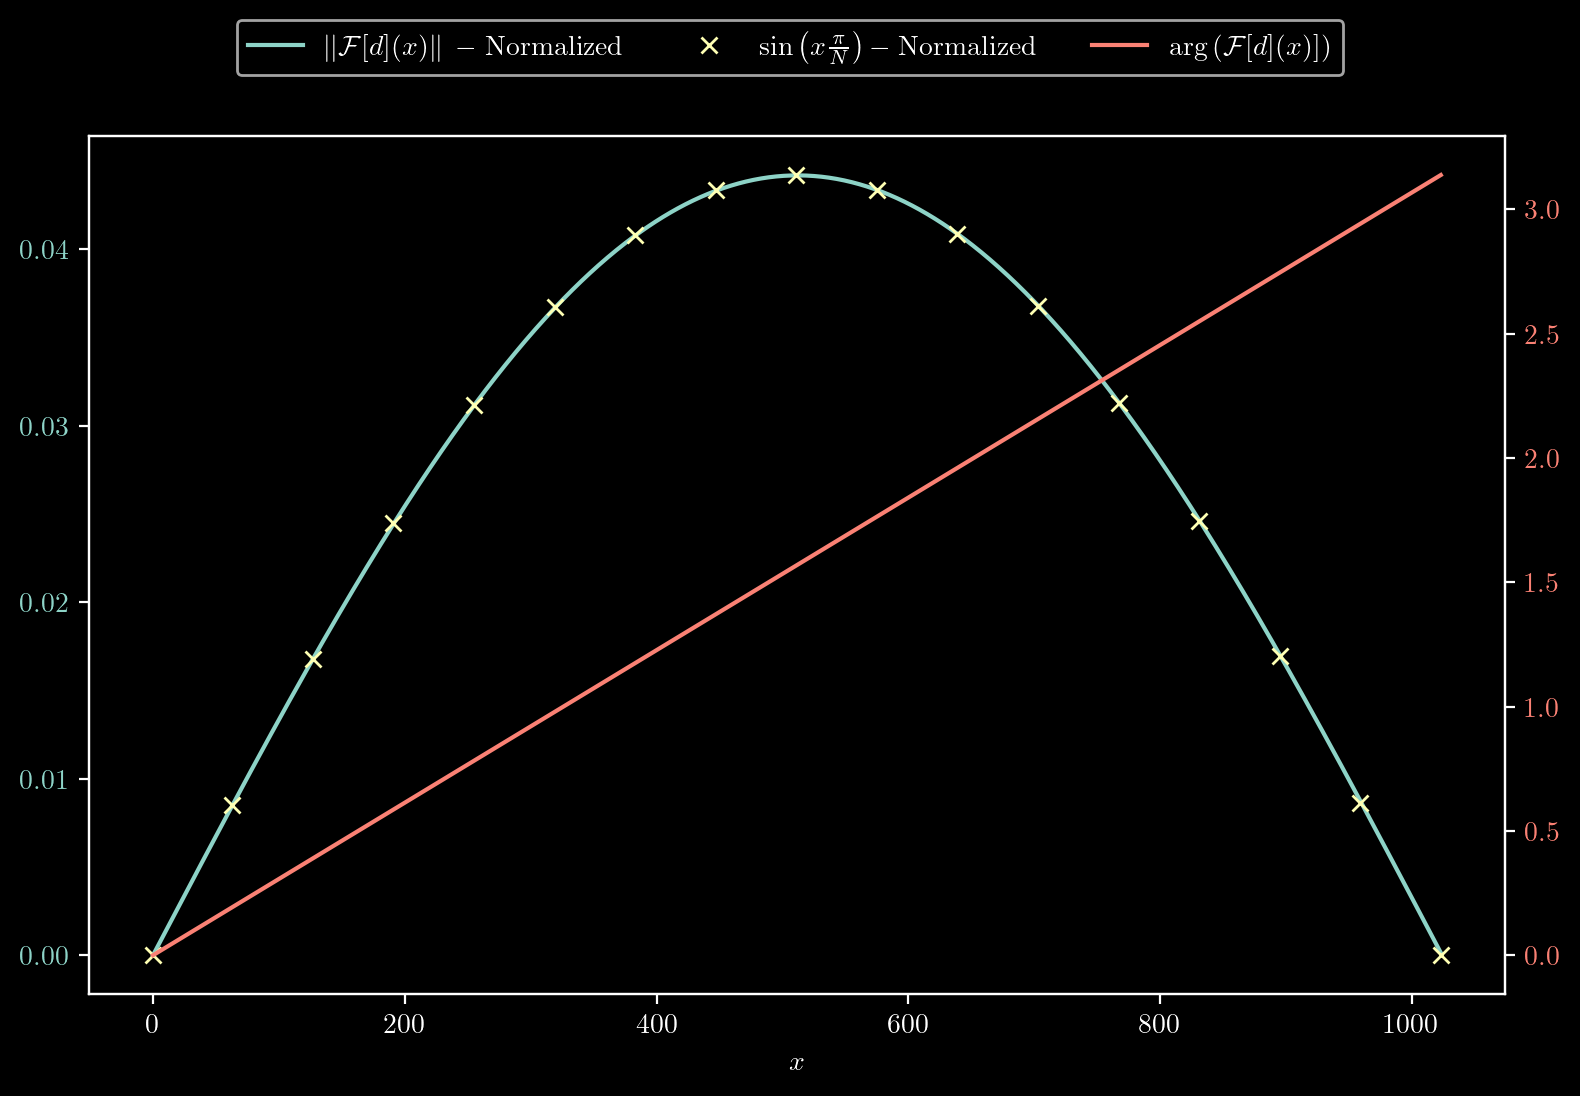

In [174]:
d_kernel = np.array([1,-1] + [0]*1022, dtype=float)
d_hat = np.fft.fft(d_kernel)
d_hat /= np.linalg.norm(d_hat)
sin_function = np.sin(np.linspace(start=0, stop=np.pi, num=len(d_hat)))
sin_function /= np.linalg.norm(sin_function)

magnitude = np.sqrt(np.real(d_hat)**2 + np.imag(d_hat)**2)
phase = np.arctan2(np.real(d_hat), np.imag(d_hat))

fig, ax1 = plt.subplots(figsize=(8,5), dpi=200)

color = 'C0'
ax1.set_xlabel('$x$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.plot(magnitude, label=r"$\left|\left| \mathcal{F}[d](x)\right|\right| \rm{\ -\ Normalized}$")
ax1.plot(
    [0] + list(np.arange(len(d_hat))[63::64]),
    [0] + list(sin_function)[63::64],
    "x", label=r"$\sin\left(x\frac{\pi}{N}\right) \rm{ -\ Normalized}$")

color = 'C3'
ax2 = ax1.twinx()
ax2.tick_params(axis='y', labelcolor=color)
ax2.plot(phase, label=r"$\arg\left(\mathcal{F}[d](x)]\right)$", color=color)

fig.tight_layout()
# fig.legend(loc="upper right")

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3)
plt.show()